<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #7c3aed; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Validación de Clusters y Métricas de Calidad 📏
      </h1>
      <p style="margin: 6px 0 0 0; color: #7c3aed; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Cluster Validation — Silhouette, Davies-Bouldin, Dunn
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #7c3aed; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 03 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #7c3aed; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/03_Validacion_de_Clusters_y_Silhouette_Score.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El Problema de la Validación Interna 📏

A diferencia de la clasificación supervisada, en clustering **no hay etiquetas de referencia**. La validación interna evalúa la calidad del clustering usando solo la estructura de los datos y las asignaciones resultantes.

### 1.1 Coeficiente de Silueta (Rousseeuw, 1987)

Para cada punto $i$:
- $a(i)$: distancia media a los demás puntos de **su propio cluster** (compacidad).
- $b(i)$: distancia media mínima a puntos de **cualquier otro cluster** (separación).

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}, \quad s(i) \in [-1, 1]$$

| Valor de $s(i)$ | Interpretación |
|-----------------|---------------|
| $s(i) \approx 1$ | Punto bien asignado: muy lejos de clusters vecinos |
| $s(i) \approx 0$ | Punto en frontera entre clusters |
| $s(i) < 0$ | Punto probablemente mal asignado |

El **Silhouette Score Global** $\bar{s}$ es la media sobre todos los puntos.

### 1.2 Otras Métricas de Validación Interna

| Métrica | Fórmula / Descripción | Optimal |
|---------|----------------------|---------|
| **Davies-Bouldin (DB)** | $\text{DB} = \frac{1}{K} \sum_k \max_{k \neq l} \frac{s_k + s_l}{d(c_k, c_l)}$ | Mínimo |
| **Índice Dunn** | $\Delta = \frac{\min_{k \neq l} d(C_k, C_l)}{\max_k \text{diam}(C_k)}$ | Máximo |
| **Calinski-Harabasz (CH)** | Ratio varianza entre-cluster / dentro-cluster | Máximo |

> **Recomendación práctica:** Usar Silhouette + Davies-Bouldin como par complementario. El primero maximizar, el segundo minimizar. La selección de $K$ que satisfaga ambos simultáneamente es la más robusta.


In [1]:
# ─── Celda 1: Setup y carga ──────────────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import os, sys, urllib.request, urllib.parse, gzip, base64

# ─── Datos embebidos (fallback sin conexión a GitHub) ─────────────────────────
_DATA_EMBEDDED = {
    "segmentacion_clientes_tienda.csv": "H4sIAAq1mGoC/21dS69uR06dI/FPDtJ2vT1mygwYR1F31IqANCJpfj/ltfZ328uH6CqDqv3V0+Xnss+vf/7pT//56y+//fHL1y9//vnPX7/+9pf/+eX3v/70829/+/k/f/qPn/72+5+//vtvv/3xt5//9Otff/vpLz///sdfv/73199//ePn33/6r19++/1+9svv//gP//wv//6v//ZPz/3Pvtr6sra/9vlauaN9zf3lt3F+tdzev2b7au3LxlfP7eNr9K9jX/Nr5+YZ367+5fPLcvv66s+X2RMdMv7+WnfwfuceXzN3nK+x70pb9MsvPFZq/U4gO7hjL7bf6fNIdhd593x3Ev254w680dEeHeoO4HfuE3scuePu+vm67WfqD2Y07hWbyKdk66thuaPpknYcx7D4XlZ0sLd7Rcv1B/61Fs5vD1lRrLzHSOdou8UPTvvqLqcX53mwtXus8oP+1fud4a71yNRtBMmcuwBtnrHGWOrWPd+Whksdem+3cSxQTBn/xPh3meWs4+CeINO76TwOD87uYo+eUbcg1X7iN3mg3uJyYn96FHeESxdB2l020AcI5Z7E1lu+pBVEfAkwVps7VpAFSNK0Aze/77kubT8xxV1wL1N7tFwSWI+039Hvu4yZXQe6J3HHutc8dW+DpH0qudwzvsdvl16nyeGNEdPGYUxtv3tecU7n0fYVhx2k14UB3Dd7f3KpMq47t5+Y+GwceW6/NOTReHecv79Xf+n0rLrhu+wBQtp6QhP869LM7c3rnHj1d5Cjn2O7dtlhYRYTDOyAuPLd3xXerng3++vJ7TuOPt6f6QR3vnuYZpWv3a/vmu5pNhn/br894IOmB7cM5H479SbvA8NNrng9eYK7oUsrl+a2bnmNaA9y1Hd5G29XUKQLL7rsY0IcKEHc07w9PZpl9IPDn19+jyK3X7qcOEwl0Lg+w8Qy+rYY2kJc6CO+i14GduN6DnejcYWXjwodBlPa8TDKMBMvtQUD0e/JCe4xH2VnG8/ovvutMmKDg/oTTCpveHusx57bKt/fG7+EbsFrlNIPuEAsaegTO5C7d/47ZF7RASfbEAX5wu7C70pDAnVtn3E1wReV2dzH1RdWNJUW7ysNBtdioHxnV8SEWOygLpnBeTlg1/kXjldsD15g3tulkktZ7nFJeU1+Jx2UKvq+Hedm/ZtkjOdF6T506hnUGFy88NK7knhMM95g3oSD/d2TuseaL/TqRDPuZ4Jgc4fHE7+Tx1R/b4+rjz3cc1WdCdzG8GTvpbbcAU6KzcmasKsVr2SJzLSrfQUJ35lCVcgddylxRfcahv5iQYEAq31yO84nKDk/B7vaV3DCjdeY2z0mDvYrNBmKyb2eS8pNt3z5X6h2Pc4uj3NVr7srCPGuP+hkABNcJncMbODOskQihCwDjc3gk3nL95yDNY+g8nzalyQuu2i4JRkILKzzX27HWxiQCvmsg4p2KH1NFJd4yZcu+ioEFqpscP4WS8rrvD9veKL70fYRVBpMQS+fmteG4Ml3Ri0qtJ2l34NjH5C3tOOO7zhHBIU1KCEbOk3e1z16KEtP0X6tQ4rejamos3gdBvXedKAeC7r3r+d8r4PrMRFQwW9C4+6xLxkG9BzHd8k9HzS1rrhgXeZ5pd996fnc7qHdq4/Vmsg0i/1DAg6xG+zSWeMp6+eNOoUHeeWJr4rU8PTLmxx41y20blnQgA7SqnZoAzIqzC5lH3d598vLOlUg2F18WEMTBkhu93jzwdeazDufD/Nd+jImNOtVVXQLdXvSqmuy0okdbxiI8gPs+NL50BO69x6LXSFP5fsV7fH2Vde30PUWrMOggtxxMFKIcv2BQ5iCX+cZ7kFMqA961OsVyjvEez7rBVUbNqPrQNCsQ6wcbYc8vlsujO5eS9ApHnI+iuBuG0qKcvardw1yj0cu7Z5n8EVq3LJSx9lRlOYj2jCU/RSj1Db41oAJKu24eg/LR3awsePLDroIfdt4x/EKlW9d3eu2h7AWzcg2xV61beweTIcNZlvnBeFOGBTS7uBYXgXEZcPQTsB489EdKKAhOU7pAJlcbqDWk90rHMHNQlpKOyzGCdNZ2icUKfBlGR8vLFZ0ykA7REFIqKO88cBIJq/OZ3rA8C/BqIjzH/aiKpvmkMfBCguvuA/4HurtLsqMU7cOJqUzO0ToPVs1AM1hWo5RlEcLBZAcsLTvaOnVMDSyp1AgTJ/+VbuC9YILpvb2QBxPWBort1ssMaSLyo/2QNsLOm1y2O2BQyW49tAfDDzxoYfdHpjI8W7K5yvobuH2ZUH7h6dFv4e7Kc7v6HJA15witxtsD/Oi4Lbwd8HqKvs1EEoojfelPLmj4+GAvmSgAQ3wYPrcPnGJM8zzvDHDEtssLK29OrgV3tvCrvo8j3yT3NIljCMKdwtfF5w/Xdd/RU0IkFWeX2tQMi8DaSKoWxAztTwxGVqDdy9MGLFh2/15SEpsTb5fuHK8Ysvt4OuhYzZtP2B0oUd1HchBic+sM9xPJ7xX6tJqnV60Vby4rTd6EWaxC1p4lQwPTazVRp3LIHilHdr0pcVeJqAbBFefjzTMOLKJPvQHECdjFQHeqHSFJia6SQv3aggPD6MhDzQgnTas2DzQPf6QZlV5a/cphQ9yFobWxni1wDH0exz+5VKXB+YrGLA449LuQPmIBm45Jn50Avj2YC9uHQncGB6k3DwfOgwarIbcgR0fqIfygwZn5lMctS30GKgZLp7dFoQIvWuV7yeUmyq12qR06tBmZGJc5GX85UgnDIl7X65XM/EIwoPY5b0uCOQQpvJ5eLo8FMqhJLFA1Pe6/NHvITb6LhKlhcZFV7Dp9/AIDNiiMj5oOq5d1Px2b5G2rgrptl798hu/WeAom26VvOEw7AZ9ePoKNp17D3wL+e5DUZ3QNAqZboQm+C9vekM23SNp+mw2ePU9UVcZt+HdMxCFjAMN5O7PlXcF94NvbChxbXhcN5TJPO9VDOhDMqWJYOkO1UcvJ1Qucq69tKO/73WKz6mFzkWeqWZqO7TXHtBL3vIBu96QdLLU/ToD1KxqB4LAYezJBJBZ4VGZokA3x/2GCDxZJWpudDpS08kdNF/ohc5LCodJi1erqm/zweiNFwutOR5ZuG309Hy9uoOV76GuhvlcJjj0RCGsIB14y/MU91u/2oQxnqQO1X431eEa0T33CDTC+S5KUWec0U6h9x5xRuqGS4efeGtedJb+IFgRD8fKQuEFoaFp8guoXZeC1YPfqTzf7R4Rjd1A2UFfXfhRN1xjr3y8G2y2Ds0ib+EeWNgl96C2MJgeri6oOvoUuoFhR1Bs6kArTi1WpKpvD09XgxvKdAJ4uu5l+tGVQrWGh0fosd/3MaGIq0rZw0dBTVlU4t5wyUEYW9sRag3Z6BJV6CGgDD7TI8+8h7OLnk71mvWGEEH4nYYuace7OSA9GeiAwYRjZeoPHJaPF47XKavDw6B76HRpXeLeehhhiMH4XKKJ9A5/PdQ+2UHoXh773UMngD1x/19up8PqoR4k7fBnzmpM9g5GZP5tfF69x2PI47xEOovLo4ctxLC+Hlxw/IWr6U1/8OMVbP0BnowxUJ7bJ/RixDGlfYHea5S8j/06TE2vOMQxLnOW76mHmMaa+nzeGIS6M3uYqfYGsOV7hM5XDXL0CZd1WCbKDybMidWKF6HTVtlwgsr39Gfec1t6AXMz9jGKJtjDUIRhLs71Pj8xt8IzFyRBh0DNF0/Fa5OuczudqGBT+YBCWNHjrsp7X/TRh2Lf9BcIS0QUeeoM1ELCUtazXrA7SbsyAxWNVnzEnapXBPhVHIS0b7AjxVnQ72bn82I55Hs4wM4pPqS+IcdCSa8/oM2IIFDW+fqedC5BicxL3YvuqK52QN/0WsPqyme3sZg4JpWM2z/iQ+MV/dD5c7ngVi5+GDu3UHTyUgMl8iAGr5cQQuCJj03pIlQvuq9C588d8xOZ10M6oLqQRkcXtN8okwal+oEacMa3ncEDHW5lfTmOe7zvU0/I4d9zL4ZSd3CIsD21mcLpwa7zMh1YJzhsSgd8XQgyy0DgW8EYp3KKOyUtOnXIdwephwE79XtE1NcoNu8IlrtBcaJbjQeOEIZvpR3B89ZLbHs8wPzQztm5fXxM0rG1Y4KaB4y33L5gPN/dZkIZoXPRozh0/RDc4YuU8xwP4sHfAhzD4GUMWSASaxgYVzwBtQGGtRdftYXSxz2vBsnkZQKoH9G+dJzJiDfMobyDcM4jdNOGDrTfOKiCn4bBWx1nd3QHDmMBobP8fYPFSJM6L6hhx2EL6ziEycV7Mh2HSLa+ixEzIk47Q9iro3k0POGIee4yw4LV+1Sn+GiwwSNGo0CwEe4uI/QmH11zslIPhpbXyvhih7aRqSLM+I1LULYyOt7xwqPKK+qglfYU5ODo2POd3CVmNF6Fy4uQGB2XHFJr6Pf7lWZ3e5m6OvARgY3QZ8mQcsSjj7z78cZ2a2R5hE/gwAl2lK4Zhx7QWvKKBlwhRvhTnnpAMRy9qEQjjrhBUm+xw8eA4txgjcnMGwr1DFqVCeDtCuqdOg50LsCTlHfNh1qjVXIJyiUCSmMWgwpdQMHErTxCGT40G3Qg7DmMf+GmY2LPbRQ/z5ig7I6oWGZ2Ez7NBaEp88L/MxEalHkRYgw4ngy/aC8aZF0+iQV7kRAfaYeScbyoaSPAdhNPs9ApHV4DJJ83sBBta3hQ+UAXEDAOtVXaN1BasKllHNA1tUGZF8zLdmWCG5GYUCmU3Le9fsKpF7MJML7SSMzXEeqLfzB0+SQ2Vb1TQHpjvwDNVoKn49W5Orxq0rEBM3Q4hHM7HGPUWKQdQKr7jNX/Mg749eUTakQOSoIxi604TqNXuZdw8ThAM4TG4doOR+rB9eSzOwgXAZeoLOHg5jvUk3xpB07cFdpnvuNQeeFuKsR4YFAhmKs8yqE+O0gm341DP4g7cLFihmPLQTP6PS+5wYGVZ3YqIY0gjNwBhHfolPoufX2w7RprGM54OlEE+VAdTs05qh7irx9kIQ74944ZgCsDU85bm499eJrqRfOhETlC15F2sNhRFdz5AKMZtF0moGpIoyW3Q2cHXFKubT54lMEr1P02H8ibVfn1fIgWIFgrT2HQuhwe6rykV/cK7IfrDxBJvpJCwxDTyL6eWaCdk8oX4/krt8PpENcWwd7cAYjEgpR/cjsU3+B3suUIMw6Yz3VFMBfpJMtbCyzFgDNVUWuzwTNgs8jx2QAKCdTt0YFwx8ALyCOcDSGZiawKmYB4r7so2UF41853/M1scIRsK2rrbAhVLkTDZdpXKOPA80KpetE4zAN1PuZmJfo/OxILfBTY9uywk/cqnsgZF0AVSH2dk4HGBj07b5m6133kqkjPDq/1ArhOvgdQy2YB+81Ojllj2DMsufeOSwei5+EV2treCCNYRd2YA/Ks1yjzDJwAvAlDX1r40jqOQnX1OZhFwMwaGYmeeqvIljngum6nBHdmhNEo7lR1mRNKEQOCeaBphOys4tGZEz7NUXG6c/ZXNdaQ/pxQRXwVKOCcCMp0RuNzO/KC9qgvaiI+0QB/lXkPAWG4UhmIpN1q3HgS3RrRTI3WzMU9U6uVDtA2Exnymqh/Eecl3wNhelpRy+b6uDUVLT0XvSGBbSorgpW2qnU6F7XcDn+9/AAUEQcoAda5CQupSQlzI8Y5iKHI7ZAIB8InM9oAjINM1bM5Ca7vBQA5N23H0C2VA+9F3BTQXNIBmqBZnI+a6tdcBVo2w+dF35Bu4BB+fAomaJ7XVz8RWcodALd7r3LzMN3tKX7EeSCE+qli88w3NwaxyNyxXtVCYX/zELjY57cZmPoVl6lP4UDfJ+vOMzhwA6t4saYjwOpeouUzZB+yadSunw4ThKIwHzXxXaGUF87s9Ng9Qb35ofl6XacaXp9BzIxZFi7lkMuB9NHLdGTMdWjm6d0s+tPglco7W89HfpjsbD2vju0lx2c9wP+0GvBdRNXfWV2sh/VANz2jxOPWA7esE2uQ2/cbYFFY4Qphc17tW76H4Th3wVsse6h7V2/3MiN/n5pjsgy+rebF2bMM6ubBSecNGHNFqOfKQEyT6ftbByFeHg8w341tZkx6AY8uO282aG86EORyhxs2f99wyWuUAOFqDCdDGc1bY8pG8Hz9vPPh0/OSO6Dsh4zSYSazCwacgLkDQRnG0PNd0usV2oAIqNUgoOgzz/ttjMYcaDupnfBZf4rwWB1E/fqQ80qZcrJbvctOH89jBcC0IssBTFxe36LTK8zVMjFgDfHKlBg7cjrPKsiy1QH+Ca3l6M0wozMMBF0Pgy7M35V24NMGIOV5QYP2RBga+n3/5MCUZzzAuVYvdsaizysUDR0fcKfz7RWPTVAemIWMc2j53HPTdqAy/CnK/prwXkckSAGcK5Ij4CxWVXNNRADnLKiQRfjeAsXIBOMTCQpXYu6YvBurRxRaG3R0hcKsCXPeqc3kduKEZlGuVoiGBYNCTau1wLrCQaDNSPs6q9ix601mfFaBJa8FC8qRvJQ3sOAcaNVdsRbwHfPbEdHl9aLkpWOTuuAJyJewDvMuW0mUXnRi7FPyxNaG1biApsycYlOkPMVBszboOo5PpdMG4e5RvG1rE1Cxim9gbSAkNoAh+W6YmBSIJ9nXRrRttKJxr0DVg3cclbrbmeNh4Pqp4yC0ileQl3OI09zF+7oOM74MMIK8r3CZ+JusmRd6xgvm3korB6x6wJme9xtgZKQ1qF95HSwlMGS6fFoS/ZTg1CK8i8ki+SAcOAcLHU3W86K7nlNgCsuJ4XuYtZE7YEKsXVSxFSrXwUiqJi+Kz/GNoxHdZQDMasem8gZMer4FP3ywwBXKL5gEFT5YoZf9PC8SWIMamz6vDRz4yu0MkdcExP0AhTghrqUdEZy4nkfHR9YX8P9HO2B07lXY7H6QqAt3Ub6G/UBfWfPbOHAVNSva2DbQNZGlO7dTIgdxm/4AWtfLsXM7AskhGXeZAZg2B+hIfjBZ/SGuVKdesMJbMWG3Ib5KiLVMAGOX4NV8FAbvNZCr8kY2naxxdk1oeDcI5ZB1emtMpvFeoAG7ESwSnnzPzfA3Guzbk9vfdOxVtJDd1psCpSlwu0HPbDUms190V58lmXE3oPjiZYqw3gQ8dEi0ltthPjXECKUdh9++LaizbMZT/aY77Foet7C73SGhQrnQHXTwnCAK3UDoXXCGLNG4N2/dV0F17+6fUMfRqxnk14A75QlYQsIRTMs7Hu0TjxOmswfqCwQX1s/Hp5iKWlubOawRrFGaC8/O+A6L20zigURuOgNdOE8B1Gw+jdC+ZHzmxgClUjqQnrRGyYvbrGeB6FHXDuAbg9jlxibQTg1eahkfnvrvHDDELutKiCG/J8PJp+Qv70lbcZaKB3syd8Xq+Sy6NEkAeUELQIsIYosc2osaGlwFeWOLtBB2dj4GpqE7IJoyL0NQvZUaIXsBsBg3rMmYmwSNpHF9NOsVyoxa5g7kuR340vLcLCMxqrDeG7qwV3TojjAfSiBtvZtN6bQrrWyy6lUSXPcGpiXsRVVY94aqeklMA4p7c8utlWDD3owyEGsjUyDken93BXLmpYfXTGhKnuIYDatvI72q11Nz7PYBt967YLf3GZ/sN93cQezGYaLJBLAKfZREus046UTiVz7tg8yDVmqI7E8ZCS+FmrYjYyok6RT7YzuBEnZKHGI7fLi9uAW2w2294MTIT9CJTCUJ5yU5LKhejdJNiyQUrKJVOEsfIUogW2C6KgA68v1bzcpKTth5IJLbKpLuPNSvW+iII7czD8oKVRzar30Wx8yJMMN5BWDP7fNjreqlnYfw1GcXE+o8r4MPj/PkDgplBi+lg2k+vSAijj2vKHJttg/QQyTRsfZCz1WbOYbHvKEB5aMzlAphDrJ8D7LuveAEj9HsXAqvPYb8zY5zyLsycHzzEjc4zDVEdQ89asYZR3XxnGYEAldY2yGsfu9vAyGnadWiOYdqV8O73LmdjvrnKVGx04CTmCSZ3I5wcq/px4clJBqd4LndP3FpNTNOf5MnvIDkT0eBhLOKB/90FoSBu1PeR/9Rr0zhQidg9Yj5DNGuT2fuefgYpnbA49VZSC23A7ETeG/TmeH/WVbgMydCjUzv1HoOh8ic2HRZEiOfRgejdEAVWd8oeIBGfRQOfwZrtN0jkZWON4LeS5DzRKhx4lRVXT4DYDpC4fLeBrimI5ziud2ZerIL1v8EWJPpWYraOtNoapyiNh1W8CLQIJ8e4fUTxkze3GTqqq3ilj8TDoJd43fnxUKhLI+sCFjzDS97JmL6od/4QWYAzL4DVkK0lMMcgLCuNSvpLMahnlMf0BtrrJiIswjrZ057nnshAy/A3Zptfl4t7OnFQ34W7vq0ot+ftQkG6AUmfhbyRuYshcLOAh9bMKVyOzH289R3sqkE9+JROszlY1E8+Z4gxvAk60o3wxSUTHlrmxmdpkj6s9cb6qqfw5SKW9Bw49mIo0coWFMyzoZ0vgvTwOt5i3m1in8450UCudaeOYf1+IIN6Pcsa7ULuuacQbTtNyl8kNrdrHi/zlmvo1QV3sOKEv0pSNJzcDOrFw/wOUTn9llAtYchClZwzKTtTGG1VSAix9sPOL3yGEfRwHlKbanjg76Gmh5//COftejU8fUennpQD0FpQDOUmZmaOUo25HEkzHxDOfjD1Ox4Ddpub+VDjbP5A+fmAThh5nbI57iZfNb+QFI5gqny+STeY5YaM/6w+pmXqLXT9TWs6OVOSj+1vqk//tGn9Qrcnhfu4RJrcWPSWTWn3ODOC9qV9RhjUb2VUhZuiEUNL5qcG7P82iw4eDfgso0pIvKL/aYQrKFTw5zyViIVbohUvHDo1N7eolYsD5Q7jMHXVRw73tqbgqRZWt4YjA9bTs60UU41EID8AE+5A08o7YvYveJh8bcaWwesQzqQPtKKA8Sbf4I58sS9P+RFiPLkcaiDNcS/PbcTH3BK8oJ3qCizApW909tnVqxs7/OFvWkQ1KmBUa89uZ3AzY6HJls4b4abl5n9xWhspd/xfNyDrXSAgBZ8uvmSRyMCf7CUX+5h5aenYO58wHkfNyMrHfOD6BRXrA8Ydo4UjHxEg8k4s2BYfSA8EwqBlQ5n+AEe/7y1ibccMkqBtU6g/UDkUdoBVKZ+Ke1voHWUOIYz+SJOtZzF5Dl3LXDjEziDOYpocULpUYdNb2ey6ICrWuvz47nXCIAvaEuDcNLcDuP6TSDJl7PaiyTU5a/+jqOy14maZQmuvJ4FA3e3Uq/GCfRivPDJ7UC2kTPL+ODhbvU9LaCekIWk57MfQmqBhs4PZwOc67UqtG/wLsfDzCvdgLYFYejnqAtrTCSWiWn0ASGfmeaGx689pZShb6CexlOqwPo+P1J7lKqJs0etlJys7wcFRZnDlQc6DBMdhf76aT/qZOr7PggehxWiuBSn64t1GqUdDpSF8Fh+x8R5eU1m8kOHfbMSvvQflbw0xucHcpd1mPJJOIzHNqoMd3urU2jRFXdUh7FWvQruncgzK4BtZ3rjrr4v9/myfXWLuMMRdAJ4JguCdn1mfR2Oe5nAkcn3P9wiPcute1nPW6BV3Dr2EN/wJrvkdni+OsMbuR2m0Ck+CHuodiEKlmGTFsXrO7Pcu04M+DWTq2Sg/SPkoe0/KsZKcMmidD0r03hmFBal6/8/gK9F6fpFN3YmCnsYRWfGjLTDoXumYpQt6tZPVogQXcOet3hq2L9bR2KIfal/0x6i5R1xD5OR4N3sUwFd9jDmSJBv/v4tKUE2kvf8Vq43La9hqFxPEIWcXetvFSMx0i3K1gNb0TSgbVG4vgGpv10Hgld4Q3RJO9ybY2lBWnsIsm9LHbEWdeuDEB/XukT2sHTtLHUdLOrWh2ftUaebPf2tAeR15s600xYKZT6hPl4ssCCZ7KHnizGjfET9U3hx6UnTtTmJtc3t2LEtdRlbVK2fyIcUL5Ohaj1rNouBZqhav98skZ3b6ewz6DJ5ZqLcbWvJXntYZnAVyJVF1frJSqZ1oMXgIjO0cweCcH1pLTd7CLGHu2oLWQyI9VHcjxaF6yfDmlNvbdoLuDr6EBhWRlVfPY3Z3yJWIvXtYfHit1yuzEDtbWkRZkPtesBoWvl+vyWGpl7PZDr6W8sqd4C0z9B6MhbF61/hqNezABpaILC8s4UQlZtCne2h4hX6/tjCmRfsxnjMgr+2h14v1m6TdrBsL7VDDdXr6XhQgllIr2G5PWkn9hM5prl9vzW+H63+Zihg/yBFyOTSdvsInaWEt+nps6UpuhYV7O+hnvKXF+xhkiPLzMsM4C2Hvubcvj81d/T2N1wq0zQZwKKA/fS3tk7e2XmzosBM8ks4sCccqtTJ7SDemLjpJZz+FpgW6IJFAftGr7ryncOiTaFW6sTgOPQMZ/I6UN4HQHqe2xGtm039i/Yw1XZt9UpYVK+fHxRHXqcbK/wx5Sh3vH+kYOgfcbCoXt+QzyCRdovi9Y1hxLNkSQ5LmSVx8tH54pmW+lwW1esH0wcKK3TiCrrCcy2q1zMJWMkodGWWJha/vQFdysIAnlHthsg1TkkqwxmAs4c6h7aDbzX67nI79C4HGrfn9vVWrnBdJySUr6JvGOFexoCnrNM/f/lGFFEzZjgS2pAXynpeyGSVl2PMcJxUO3M7jIrR1KY3wKogNIW/G0H2vX8bHq6Bgz3LOvcLPB26TKYqHymzYMaoo896Le1FiRRnoQVNvZ6n7ISxt8Y2qp3n8Vm1/qB0rHw+XuNctRkjTmYeNawMVevXS28yPjW6VXbbyL2fo7mNhtoHrF2mGmu0dKYFC7bN3ph7bERMKIOYQel6KcpoRlXjdE1UNZQWhubS9AqYE4hKhDoxHZFHC12YsZAXEEv6NDoLxxorjuYOxFmDb8pA4yHydKthYvS+nKNeMDOC7hdfZW6Hk5uwVBlnUItqypCNpT7H1MK6Zizxa4y/SwfTeKeWFreoXD+QYCQVBMwIsTfXqJgZy32MrWVpzejqmrtIICMMtZc/CWVRt54WuDiDDXXrB3MWyg+IUo2sC3kFVLlsq7fOjAD78Ozr+Aw1WqkfYFG2fjEMLepElK0Hb1oK97AoXD/Wm6kh7e2txbj1uS4IAEP5rzwxy9Y73BcyMd1EU3GQFmXrwV1HMKi8Y4YZ+1LYtxmjjMYUZpnBP0e6lSgYZ9ylvKahbj1hGkqlmxCA4lW2qFvPShcSvbWoW8+s6aGciyZhnxocNGMJ1d61Ir9F3XqWdDm6482/9fA0zfcwo7MLxTt1BlZXPyXZ2YzeLpQhyM/vgAlt1GDOd8mkxnho+vn4kZ2uB3dwCrtr/WozIuz7LhpmVK1nJdGh+zrnJThV86NoPZzr5S+wWJStb/utzZzPwe0DC9TnzUJeyFVacsVMatxLweYWRetZvcW3fo9cm7dWbm6nlhJcXCcGymua5kaaUdkiilHGIUwiNpe/b2/11Kua0MHzf56Nhq3wcQAA",
    "transacciones_supermercado.csv":   "...",
}

def load_dataset(filename: str) -> str:
    """Devuelve la ruta local al CSV. Descarga de GitHub o restaura desde datos embebidos."""
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join(os.path.dirname(os.path.abspath(".")), "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    # Intento de descarga remota (GitHub)
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=4)
        print(f"[load_dataset] Descargado: {filename}")
        return target
    except Exception:
        pass
    # Restauración desde datos embebidos (funciona siempre, sin red)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        print(f"[load_dataset] Restaurado desde datos embebidos: {filename}")
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

print("setup_colab.py cargado correctamente.")


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              davies_bouldin_score, calinski_harabasz_score)

df = pd.read_csv(load_dataset("segmentacion_clientes_tienda.csv"))
features = ['edad', 'ingreso_anual_k_usd', 'puntuacion_gasto', 'visitas_mensuales']
X = df[features].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print(f"Dataset: {X_std.shape[0]} puntos × {X_std.shape[1]} dimensiones")


setup_colab.py cargado correctamente.
Dataset: 1200 puntos × 4 dimensiones


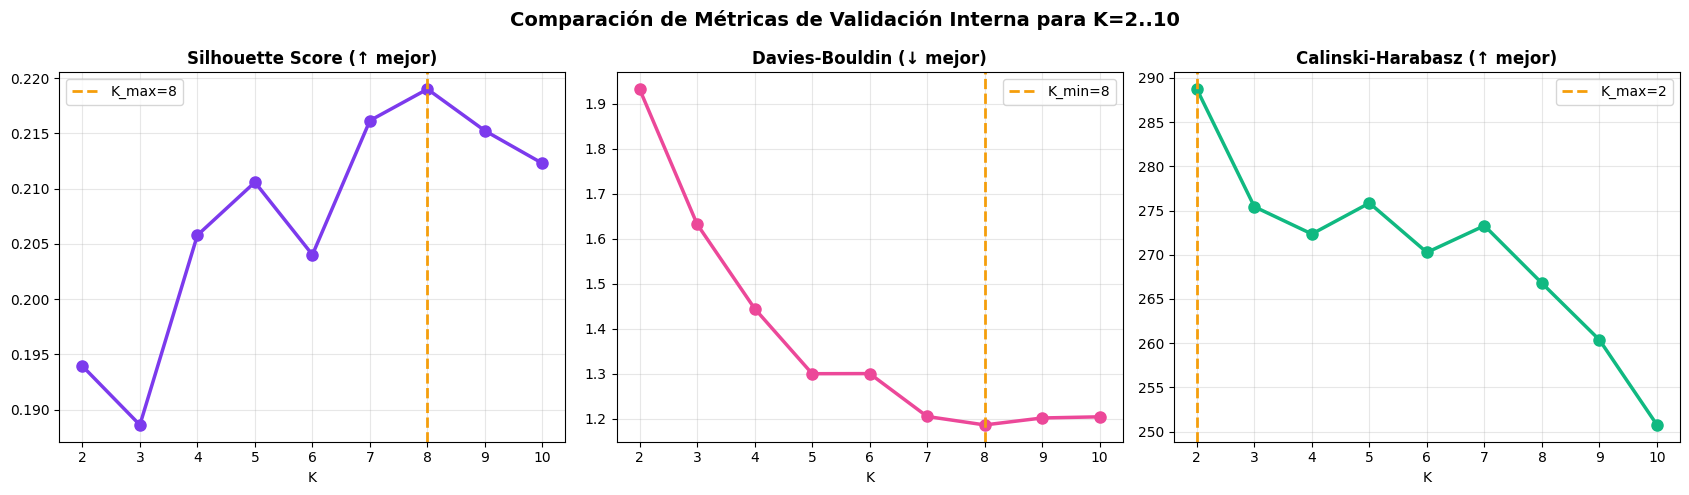

K óptimo por Silhouette: 8 (s=0.2190)
K óptimo por Davies-Bouldin: 8 (DB=1.1865)
K óptimo por Calinski-Harabasz: 2 (CH=288.7)


In [2]:
# ─── Celda 2: Comparación de métricas para K=2..10 ─────────────────────────
K_range = range(2, 11)
sil_scores, db_scores, ch_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    lbl = km.fit_predict(X_std)
    sil_scores.append(silhouette_score(X_std, lbl))
    db_scores.append(davies_bouldin_score(X_std, lbl))
    ch_scores.append(calinski_harabasz_score(X_std, lbl))

Ks = list(K_range)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(Ks, sil_scores, 'o-', color='#7c3aed', linewidth=2.5, markersize=8)
axes[0].axvline(x=Ks[np.argmax(sil_scores)], color='#f59e0b', linestyle='--', linewidth=2,
                label=f"K_max={Ks[np.argmax(sil_scores)]}")
axes[0].set_title('Silhouette Score (↑ mejor)', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(Ks, db_scores, 'o-', color='#ec4899', linewidth=2.5, markersize=8)
axes[1].axvline(x=Ks[np.argmin(db_scores)], color='#f59e0b', linestyle='--', linewidth=2,
                label=f"K_min={Ks[np.argmin(db_scores)]}")
axes[1].set_title('Davies-Bouldin (↓ mejor)', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(Ks, ch_scores, 'o-', color='#10b981', linewidth=2.5, markersize=8)
axes[2].axvline(x=Ks[np.argmax(ch_scores)], color='#f59e0b', linestyle='--', linewidth=2,
                label=f"K_max={Ks[np.argmax(ch_scores)]}")
axes[2].set_title('Calinski-Harabasz (↑ mejor)', fontweight='bold')
axes[2].set_xlabel('K')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Comparación de Métricas de Validación Interna para K=2..10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"K óptimo por Silhouette: {Ks[np.argmax(sil_scores)]} (s={max(sil_scores):.4f})")
print(f"K óptimo por Davies-Bouldin: {Ks[np.argmin(db_scores)]} (DB={min(db_scores):.4f})")
print(f"K óptimo por Calinski-Harabasz: {Ks[np.argmax(ch_scores)]} (CH={max(ch_scores):.1f})")


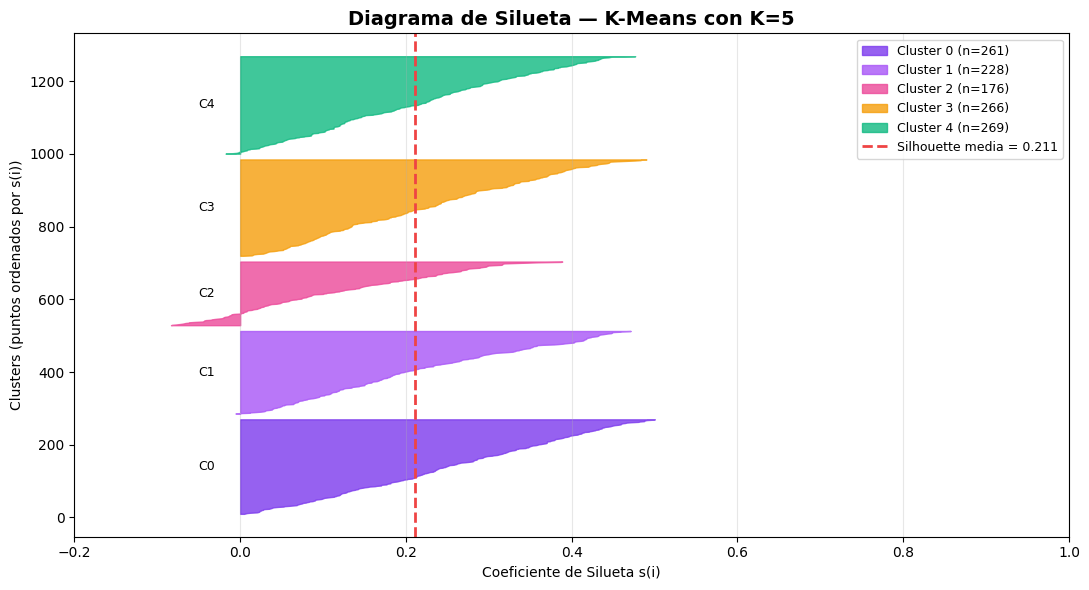


Silhouette global: 0.2106
  Cluster 0: s_media=0.2520 | 261 puntos
  Cluster 1: s_media=0.2176 | 228 puntos
  Cluster 2: s_media=0.1171 | 176 puntos
  Cluster 3: s_media=0.2262 | 266 puntos
  Cluster 4: s_media=0.2101 | 269 puntos


In [3]:
# ─── Celda 3: Diagrama de silueta completo ──────────────────────────────────
K_BEST = 5
km = KMeans(n_clusters=K_BEST, init='k-means++', n_init=20, random_state=42)
labels = km.fit_predict(X_std)
sil_vals = silhouette_samples(X_std, labels)
sil_mean = np.mean(sil_vals)

palette = ['#7c3aed', '#a855f7', '#ec4899', '#f59e0b', '#10b981']
fig, ax = plt.subplots(figsize=(11, 6))
y_lower = 10
for k in range(K_BEST):
    k_vals = np.sort(sil_vals[labels == k])
    y_upper = y_lower + len(k_vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, k_vals,
                     color=palette[k], alpha=0.8, label=f'Cluster {k} (n={len(k_vals)})')
    ax.text(-0.05, (y_lower + y_upper) / 2, f'C{k}', fontsize=9, va='center')
    y_lower = y_upper + 15

ax.axvline(x=sil_mean, color='#ef4444', linestyle='--', linewidth=2,
           label=f'Silhouette media = {sil_mean:.3f}')
ax.set_xlim([-0.2, 1.0])
ax.set_title(f'Diagrama de Silueta — K-Means con K={K_BEST}', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente de Silueta s(i)')
ax.set_ylabel('Clusters (puntos ordenados por s(i))')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Reporte por cluster
print(f"\nSilhouette global: {sil_mean:.4f}")
for k in range(K_BEST):
    k_mean = np.mean(sil_vals[labels == k])
    print(f"  Cluster {k}: s_media={k_mean:.4f} | {np.sum(labels==k)} puntos")


In [4]:
# ─── Celda 4: Ejercicio — Comparar K-Means vs. Jerárquico en métricas ────────
from sklearn.cluster import AgglomerativeClustering

K = 5
km = KMeans(n_clusters=K, init='k-means++', n_init=20, random_state=42)
lbl_km = km.fit_predict(X_std)
hc = AgglomerativeClustering(n_clusters=K, linkage='ward')
lbl_hc = hc.fit_predict(X_std)

print("=== Comparación K-Means vs. Clustering Jerárquico Ward ===")
print(f"{'Métrica':<30} {'K-Means':>12} {'Jerárquico':>12}")
print("-" * 56)
print(f"{'Silhouette Score':<30} {silhouette_score(X_std, lbl_km):>12.4f} {silhouette_score(X_std, lbl_hc):>12.4f}")
print(f"{'Davies-Bouldin':<30} {davies_bouldin_score(X_std, lbl_km):>12.4f} {davies_bouldin_score(X_std, lbl_hc):>12.4f}")
print(f"{'Calinski-Harabasz':<30} {calinski_harabasz_score(X_std, lbl_km):>12.1f} {calinski_harabasz_score(X_std, lbl_hc):>12.1f}")


=== Comparación K-Means vs. Clustering Jerárquico Ward ===
Métrica                             K-Means   Jerárquico
--------------------------------------------------------
Silhouette Score                     0.2106       0.1717
Davies-Bouldin                       1.3003       1.5349
Calinski-Harabasz                     275.8        226.5


---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos · Data Mining · Módulo 03</i><br>
    Docente: Santiago A. Zúñiga M. | <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #7c3aed;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
  </p>
</div>